# Краткий анализ результатов ex1_v3

Сравнение двух запусков — `qwen3-0.6b` и `qwen3-4b-awq` — по данным из `outputs/runs/ex1_v3`. Анализ фокусируется на качестве прогонов, частоте выбора H1, точности, влиянии prior/порядка гипотез и согласии моделей.

In [1]:
from pathlib import Path
import json

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

pd.set_option("display.max_columns", 30)
plt.style.use("seaborn-v0_8-whitegrid")

start = Path.cwd().resolve()
project_root = next(
    (p for p in [start, *start.parents] if (p / "outputs" / "runs" / "ex1_v3").is_dir()),
    None,
)
if project_root is None:
    raise FileNotFoundError("Не найдена папка outputs/runs/ex1_v3")

runs_dir = project_root / "outputs" / "runs" / "ex1_v3"
metrics_by_model = {}
manifests_by_model = {}
response_frames = []

for run_dir in sorted(p for p in runs_dir.iterdir() if p.is_dir()):
    metrics = json.loads((run_dir / "metrics.json").read_text(encoding="utf-8"))
    manifest = json.loads((run_dir / "manifest.json").read_text(encoding="utf-8"))
    model = metrics["model"]
    metrics_by_model[model] = metrics
    manifests_by_model[model] = manifest

    responses = pd.read_json(run_dir / "responses.jsonl", lines=True)
    responses["model"] = model
    response_frames.append(responses)

all_responses = pd.concat(response_frames, ignore_index=True)
print(f"Загружено {len(metrics_by_model)} запуска и {len(all_responses):,} ответов из {runs_dir}")

Загружено 2 запуска и 4,800 ответов из D:\Scientific activity\master-thesis\outputs\runs\ex1_v3


## 1. Полнота прогонов

In [2]:
quality_rows = []
for model, m in metrics_by_model.items():
    manifest = manifests_by_model[model]
    started = pd.to_datetime(manifest["started_at"], format="%Y%m%dT%H%M%SZ", utc=True)
    finished = pd.to_datetime(manifest["finished_at"], format="%Y%m%dT%H%M%SZ", utc=True)
    quality_rows.append({
        "model": model,
        "planned": m["total_planned"],
        "completed": m["completed"],
        "failed": m["failed"],
        "invalid": m["invalid_responses"],
        "duration_min": (finished - started).total_seconds() / 60,
    })

quality = pd.DataFrame(quality_rows).sort_values("model").reset_index(drop=True)
display(quality.round({"duration_min": 1}))

,model,planned,completed,failed,invalid,duration_min
0,qwen3-0.6b,2400,2400,0,0,9.0
1,qwen3-4b-awq,2400,2400,0,0,37.3


## 2. Главный результат: почти постоянный выбор H1

,model,prior,n,"H1, %","accuracy, %","совпадение с ожидаемым выбором, %"
0,qwen3-0.6b,neutral,1200,99.75,49.92,40.08
1,qwen3-0.6b,wrong,1200,100.00,50.00,75.67
2,qwen3-4b-awq,neutral,1200,99.92,50.08,39.92
3,qwen3-4b-awq,wrong,1200,100.00,50.00,75.67


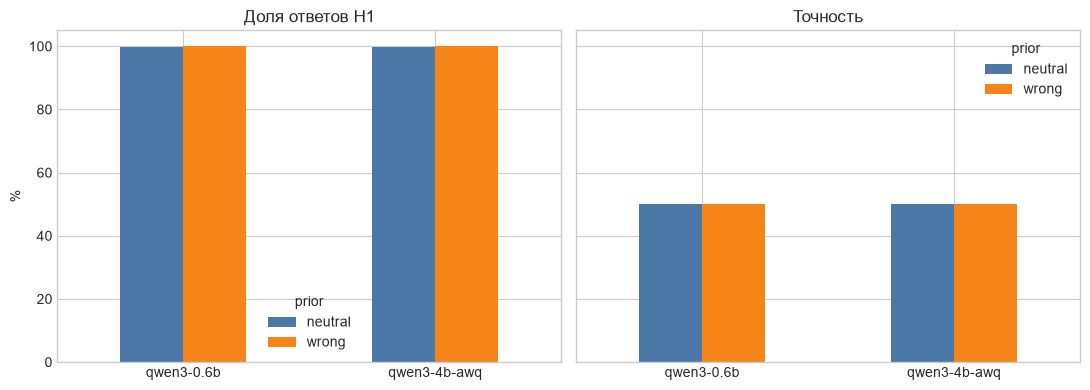

In [3]:
condition_rows = []
for model, m in metrics_by_model.items():
    for prior, values in m["conditions"].items():
        condition_rows.append({
            "model": model,
            "prior": prior,
            "n": values["n"],
            "H1, %": 100 * values["p_h1"],
            "accuracy, %": 100 * values["accuracy"],
            "совпадение с ожидаемым выбором, %": 100 * values["p_expected_choice_matches"],
        })

conditions = pd.DataFrame(condition_rows).sort_values(["model", "prior"])
display(conditions.round(2))

fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=True)
for ax, metric, title in zip(
    axes,
    ["H1, %", "accuracy, %"],
    ["Доля ответов H1", "Точность"],
):
    conditions.pivot(index="model", columns="prior", values=metric).plot(
        kind="bar", ax=ax, color=["#4C78A8", "#F58518"]
    )
    ax.set_title(title)
    ax.set_xlabel("")
    ax.set_ylabel("%")
    ax.set_ylim(0, 105)
    ax.tick_params(axis="x", rotation=0)
    ax.legend(title="prior")
plt.tight_layout()
plt.show()

При сбалансированных H0/H1 общая точность около 50% сама по себе вводит в заблуждение: она возникает из-за стратегии «почти всегда H1», а не из-за различения гипотез.

In [4]:
truth_rows = []
order_rows = []
for model, m in metrics_by_model.items():
    for values in m["true_hypothesis_conditions"]:
        truth_rows.append({
            "model": model,
            "prior": values["prior"],
            "истинная гипотеза": values["right_hypothesis"],
            "n": values["n"],
            "H1, %": 100 * values["p_h1"],
            "accuracy, %": 100 * values["accuracy"],
        })
    for values in m["hypothesis_order_conditions"]:
        order_rows.append({
            "model": model,
            "prior": values["prior"],
            "порядок": values["hypothesis_order"],
            "H1, %": 100 * values["p_h1"],
            "accuracy, %": 100 * values["accuracy"],
        })

truth = pd.DataFrame(truth_rows).sort_values(["model", "prior", "истинная гипотеза"])
order = pd.DataFrame(order_rows).sort_values(["model", "prior", "порядок"])
print("Разбиение по истинной гипотезе:")
display(truth.round(2))
print("Проверка эффекта порядка предъявления:")
display(order.round(2))

Разбиение по истинной гипотезе:


,model,prior,истинная гипотеза,n,"H1, %","accuracy, %"
0,qwen3-0.6b,neutral,H0,600,99.83,0.17
1,qwen3-0.6b,neutral,H1,600,99.67,99.67
2,qwen3-0.6b,wrong,H0,600,100.00,0.00
3,qwen3-0.6b,wrong,H1,600,100.00,100.00
4,qwen3-4b-awq,neutral,H0,600,99.83,0.17
5,qwen3-4b-awq,neutral,H1,600,100.00,100.00
6,qwen3-4b-awq,wrong,H0,600,100.00,0.00
7,qwen3-4b-awq,wrong,H1,600,100.00,100.00


Проверка эффекта порядка предъявления:


,model,prior,порядок,"H1, %","accuracy, %"
0,qwen3-0.6b,neutral,H0_H1,100.00,50.00
1,qwen3-0.6b,neutral,H1_H0,99.50,49.83
2,qwen3-0.6b,wrong,H0_H1,100.00,50.00
3,qwen3-0.6b,wrong,H1_H0,100.00,50.00
4,qwen3-4b-awq,neutral,H0_H1,100.00,50.00
5,qwen3-4b-awq,neutral,H1_H0,99.83,50.17
6,qwen3-4b-awq,wrong,H0_H1,100.00,50.00
7,qwen3-4b-awq,wrong,H1_H0,100.00,50.00


## 3. Сила свидетельств

В этих данных `target_evidence_strength` заполнена только для случаев с истинной H1. Поэтому график ниже следует читать как проверку чувствительности ответа внутри ветки H1, а не как общий показатель точности.

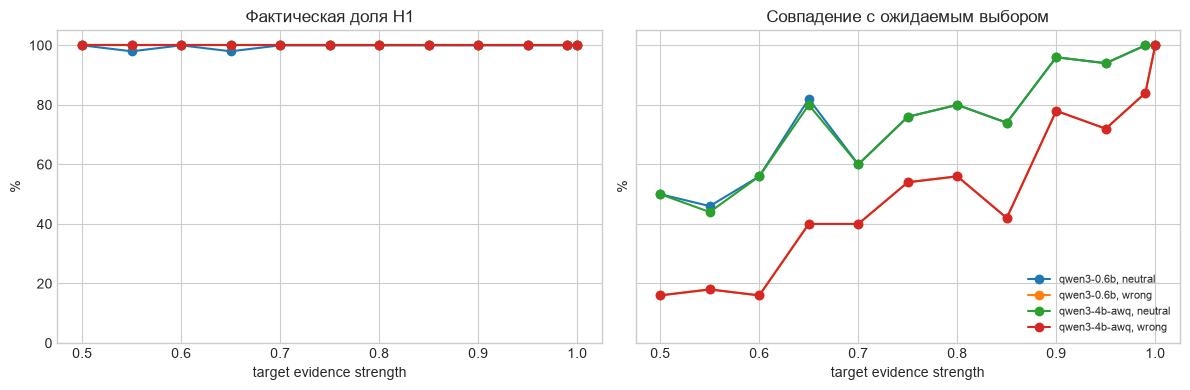

In [5]:
evidence_rows = []
for model, m in metrics_by_model.items():
    for values in m["evidence_strength"]:
        evidence_rows.append({
            "model": model,
            "prior": values["prior"],
            "target_strength": values["target_evidence_strength"],
            "H1, %": 100 * values["p_h1"],
            "совпадение с ожидаемым выбором, %": 100 * values["p_expected_choice_matches"],
        })

evidence = pd.DataFrame(evidence_rows).sort_values(["model", "prior", "target_strength"])
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharex=True, sharey=True)
for (model, prior), part in evidence.groupby(["model", "prior"], sort=True):
    label = f"{model}, {prior}"
    axes[0].plot(part["target_strength"], part["H1, %"], marker="o", label=label)
    axes[1].plot(
        part["target_strength"],
        part["совпадение с ожидаемым выбором, %"],
        marker="o",
        label=label,
    )
axes[0].set_title("Фактическая доля H1")
axes[1].set_title("Совпадение с ожидаемым выбором")
for ax in axes:
    ax.set_xlabel("target evidence strength")
    ax.set_ylabel("%")
    ax.set_ylim(0, 105)
axes[1].legend(loc="lower right", fontsize=8)
plt.tight_layout()
plt.show()

## 4. Согласие моделей

In [6]:
pair_keys = ["dataset_id", "prior", "hypothesis_order", "right_hypothesis"]
paired = all_responses.pivot(index=pair_keys, columns="model", values="answer")
disagreement_mask = paired.nunique(axis=1) > 1
n_disagree = int(disagreement_mask.sum())
agreement_pct = 100 * (1 - n_disagree / len(paired))

answer_counts = (
    all_responses.groupby(["model", "answer"]).size().unstack(fill_value=0).reset_index()
)
display(answer_counts)
print(f"Совпадение ответов моделей: {len(paired) - n_disagree}/{len(paired)} ({agreement_pct:.2f}%).")
print(f"Расхождений: {n_disagree}.")
if n_disagree:
    display(paired.loc[disagreement_mask].reset_index())

answer,model,H0,H1
0,qwen3-0.6b,3,2397
1,qwen3-4b-awq,1,2399


Совпадение ответов моделей: 2396/2400 (99.83%).
Расхождений: 4.


model,dataset_id,prior,hypothesis_order,right_hypothesis,qwen3-0.6b,qwen3-4b-awq
0,dataset_h0_04_048,neutral,H1_H0,H0,H1,H0
1,dataset_h0_04_050,neutral,H1_H0,H0,H0,H1
2,dataset_h1_02_018,neutral,H1_H0,H1,H0,H1
3,dataset_h1_04_014,neutral,H1_H0,H1,H0,H1


## Вывод

- Оба прогона технически полные: по 2400/2400 ответов, без failures и invalid responses.
- Обе модели почти детерминированно выбирают H1 (99.75–100% ответов). Поэтому около 50% общей accuracy — следствие баланса классов, а не содержательного различения H0 и H1.
- Для истинной H0 точность практически нулевая, для истинной H1 — практически 100%. Значимого эффекта порядка гипотез не видно.
- Увеличение модели с 0.6B до 4B-AWQ не меняет паттерн: ответы совпадают в 2396 из 2400 случаев (99.83%).
- Практический итог: в текущей постановке эксперимент прежде всего выявляет сильное смещение к метке H1. Перед интерпретацией prior и силы свидетельств стоит проверить формулировку промпта, парсинг ответа и возможный label/format bias.